# Coupe du Monde 2026

Prolongement du TD de prédiction de matchs internationaux. Le TD s'arrête à un
RandomForest sur cinq features, autour de 65% de bonnes réponses. Ce notebook
reprend le problème depuis la donnée brute et mesure ce qu'on gagne à chaque étape.

Ordre des parties, qui est aussi leur ordre d'impact :

1. Périmètre des équipes (le dataset contient des sélections non FIFA)
2. Un Elo, ajusté à la force de l'adversaire
3. Cadrage antisymétrique du problème
4. Géographie : altitude, voyage, climat
5. Évaluation : split chronologique, log loss
6. Benchmark de modèles, XGBoost tuné, TabICL
7. Explicabilité : qu'est-ce qui décide réellement
8. Sélection de features
9. Simulation du tournoi et rétro-test

In [31]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from world_soccer_2026 import backtest, explain, selection_features as sf
from world_soccer_2026.benchmark import (fit_best_xgboost, make_xy, preprocessor,
                                         run_benchmark, score, temporal_split,
                                         tune_xgboost)
from world_soccer_2026.features import (FEATURES, FEATURES_NO_GEO, FEATURES_SELECTED,
                                        FEATURES_TD, JEUX_DE_FEATURES,
                                        build_pair_frame, prepare)
from world_soccer_2026.fixtures import DEMI_FINALES, FINALE, WC_START
from world_soccer_2026.geo import load_coords, team_home_base
from world_soccer_2026.selection import diagnose, select_teams
from world_soccer_2026.tournament import (build_pair_matrix, flatten,
                                          simulate_monte_carlo)
from world_soccer_2026.utils import load_results

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Périmètre des équipes

Le dataset de martj42 contient des sélections non affiliées à la FIFA : équipes
régionales (Occitanie, Andalousie), Jeux insulaires (Jersey, Ynys Môn), ConIFA.

Ce n'est pas qu'une question de propreté. Un Elo suppose que le graphe des
confrontations soit connexe : si un groupe d'équipes ne joue qu'entre elles, leurs
notes dérivent sur une échelle propre, sans commune mesure avec celle des sélections
FIFA. Le modèle recevrait des nombres d'apparence comparable qui ne le sont pas.

On coupe aussi au **11 juin 2026**, coup d'envoi du tournoi. La coupure porte sur
l'entraînement *et* sur l'état des équipes : si l'Elo de la France intégrait ses
matchs de Coupe du Monde, la fuite passerait par la feature.

In [32]:
raw = load_results("../data/results.csv")
raw = raw[(raw["year"] >= 1994) & (raw["date"] < WC_START)]
print(f"{len(raw)} matchs, du {raw.date.min().date()} au {raw.date.max().date()}\n")

composantes, hors_fifa = diagnose(raw)

29902 matchs, du 1994-01-02 au 2026-06-10

323 équipes, 29902 matchs
2 composante(s) connexe(s), la principale en compte 320
  isolée : ['Aymara', 'Mapuche', 'Maule Sur']

112 équipes sans aucun match FIFA (Coupe du Monde ou qualification)
Martinique       189
Guadeloupe       158
French Guiana    125
Jersey           109
Guernsey         102
Zanzibar          90
Saint Martin      65
Greenland         58
Ynys Môn          55
Isle of Man       54
Alderney          53
Réunion           50
Sint Maarten      49
Shetland          46
Padania           45


In [33]:
raw, equipes = select_teams(raw, min_matches=50, require_fifa=True)

117 équipes retirées, 206 conservées
1896 matchs écartés, 28006 conservés (93.7%)


## 2. Un Elo

La feature du TD, `avg_points` sur 10 matchs, mesure la forme mais pas l'adversité
rencontrée. Une équipe qui domine une zone faible et une équipe qui survit dans une
zone forte affichent la même moyenne.

L'Elo corrige cela : battre une équipe forte rapporte beaucoup, battre une équipe
faible rapporte peu, et la mise à jour est proportionnelle à la surprise du résultat.

Ce n'est pas une invention maison. Arpad Elo l'a conçu vers 1960 pour les échecs ;
eloratings.net l'a adapté au football (écart de buts, enjeu du match, avantage du
terrain), et la FIFA a adopté un système Elo pour son classement masculin en 2018.
Les constantes du code (bonus de 100 points à domicile, diviseur 400, poids 20 à 60
selon l'enjeu) viennent de la spécification eloratings.net.

In [34]:
df, ratings, base, snapshots = prepare(raw)

print(f"{len(df)} matchs exploitables, {len(FEATURES)} features")
print(f"{len(snapshots)} équipes avec un état courant\n")

pd.Series(ratings).sort_values(ascending=False).head(15).round(0).to_frame("elo")

20985 matchs exploitables, 22 features
206 équipes avec un état courant



,elo
Spain,2171.0000
Argentina,2159.0000
France,2076.0000
Brazil,2030.0000
Colombia,2029.0000
England,2028.0000
Portugal,2022.0000
Ecuador,1969.0000
Japan,1961.0000
Netherlands,1961.0000


### Comparaison des deux classements

À gauche ce que voit la feature du TD, à droite ce que voit l'Elo. La colonne
`elo_adversaires` explique l'écart.

In [35]:
from world_soccer_2026.features import add_elo

tmp, _ = add_elo(raw.copy())

lignes = []
for team in sorted(set(raw.home_team) | set(raw.away_team)):
    m = tmp[(tmp.home_team == team) | (tmp.away_team == team)].tail(10)
    if len(m) < 10:
        continue
    dom = m.home_team == team
    gs = np.where(dom, m.home_score, m.away_score)
    gc = np.where(dom, m.away_score, m.home_score)
    lignes.append({
        "equipe": team,
        "pts_moyens": np.where(gs > gc, 3, np.where(gs == gc, 1, 0)).mean(),
        "elo_adversaires": np.where(dom, m.away_elo, m.home_elo).mean(),
        "elo": ratings[team],
    })

naive = pd.DataFrame(lignes).sort_values("pts_moyens", ascending=False)
naive.head(15).reset_index(drop=True).round(0)

,equipe,pts_moyens,elo_adversaires,elo
0,Germany,3.0000,1620.0000,1948.0000
1,Vietnam,3.0000,1227.0000,1510.0000
2,England,2.0000,1666.0000,2028.0000
3,France,2.0000,1684.0000,2076.0000
4,Argentina,2.0000,1670.0000,2159.0000
5,Austria,2.0000,1448.0000,1837.0000
6,Turkey,2.0000,1748.0000,1905.0000
7,Philippines,2.0000,1230.0000,1362.0000
8,Italy,2.0000,1566.0000,1899.0000
9,Spain,2.0000,1705.0000,2171.0000


Les équipes en tête du classement naïf sont celles qui ont affronté les adversaires
les plus faibles. Le Brésil, qui joue les qualifs CONMEBOL, tombe au milieu du tableau.

La feature du TD n'est pas fausse : elle mesure « qui a gagné ses dix derniers
matchs ». C'est une information réelle, simplement incomplète.

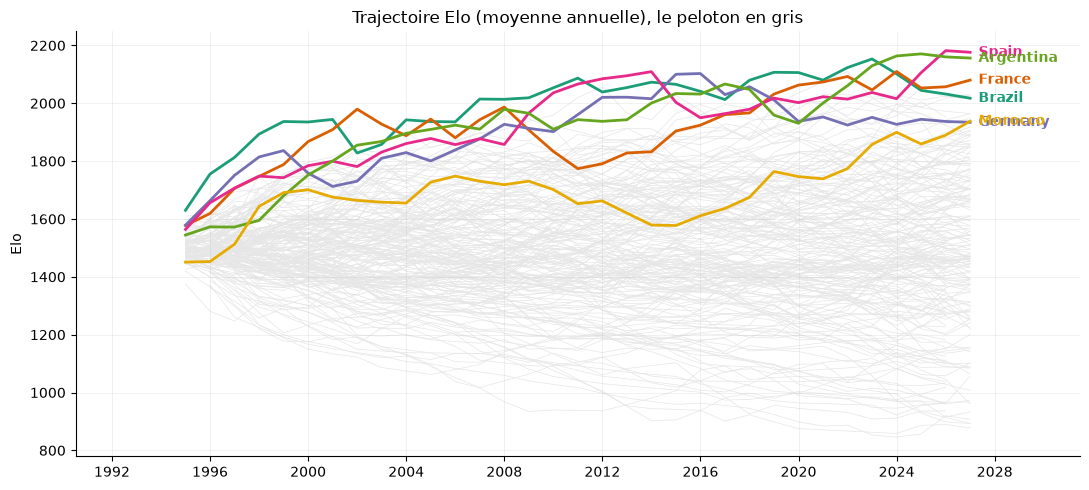

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))
PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
SUIVIES = ["Brazil", "France", "Germany", "Spain", "Argentina", "Morocco"]

def serie_elo(team):
    m = df[(df.home_team == team) | (df.away_team == team)]
    s = pd.Series(np.where(m.home_team == team, m.home_elo, m.away_elo),
                  index=pd.to_datetime(m["date"]))
    return s.resample("YE").mean().dropna()

for t in set(df.home_team) | set(df.away_team):
    if t not in SUIVIES:
        s = serie_elo(t)
        if len(s) > 5:
            ax.plot(s.index, s.values, color="0.9", lw=.5, zorder=1)

for team, c in zip(SUIVIES, PALETTE):
    s = serie_elo(team)
    ax.plot(s.index, s.values, color=c, lw=2, zorder=3)
    ax.annotate(team, xy=(s.index[-1], s.values[-1]), xytext=(6, 0),
                textcoords="offset points", color=c, fontsize=10,
                fontweight="bold", va="center")

ax.set_title("Trajectoire Elo (moyenne annuelle), le peloton en gris")
ax.set_ylabel("Elo"); ax.grid(alpha=.25, lw=.5); ax.margins(x=.14)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Antisymétrie

Le modèle apprend « domicile contre extérieur ». Or un tournoi se joue en terrain
neutre : la notion de domicile disparaît.

`build_pair_frame` reformule chaque match en « A contre B », avec
`home_advantage ∈ {-1, 0, +1}` et toutes les autres features en différences A moins B.
On peut alors dupliquer chaque match en miroir (cible inversée), ce qui double le
train et apprend au modèle que le problème est antisymétrique.

Trois états à mesurer : sans miroir, avec miroir, et avec moyennage explicite.

In [37]:
from sklearn.ensemble import RandomForestClassifier

train_df, test_df = temporal_split(df, test_year=2022)
X_tr, y_tr = make_xy(train_df, mirror=True)
X_te, y_te = make_xy(test_df, mirror=False)


def violations(predict_fn, test_df):
    """|p(A,B) + p(B,A) - 1| par match, et masque des matchs neutres."""
    mir = build_pair_frame(test_df, mirror=True)
    h = len(mir) // 2
    ab, ba = mir.iloc[:h], mir.iloc[h:]
    v = np.abs(predict_fn(ab[FEATURES]) + predict_fn(ba[FEATURES]) - 1)
    return v, (ab["home_advantage"] == 0).to_numpy()


def rf(X, y):
    return Pipeline([("prep", preprocessor()),
                     ("clf", RandomForestClassifier(n_estimators=200,
                                                    random_state=42,
                                                    n_jobs=-1))]).fit(X, y)


rf_naif = rf(*make_xy(train_df, mirror=False))
rf_miroir = rf(X_tr, y_tr)


def symetrise(model):
    """p = (p(A,B) + 1 - p(B,A)) / 2. Antisymétrie exacte, par arithmétique."""
    def f(X):
        X_inv = X.copy()
        for c in [c for c in FEATURES if c.startswith("diff_")] + ["home_advantage"]:
            X_inv[c] = -X_inv[c]
        X_inv["h2h_winrate"] = 1 - X["h2h_winrate"]
        return .5 * (model.predict_proba(X)[:, 1]
                     + 1 - model.predict_proba(X_inv)[:, 1])
    return f


etats = {
    "sans miroir": lambda X: rf_naif.predict_proba(X)[:, 1],
    "entraîné en miroir": lambda X: rf_miroir.predict_proba(X)[:, 1],
    "miroir + moyennage": symetrise(rf_miroir),
}

lignes = []
for nom, f in etats.items():
    v, neutre = violations(f, test_df)
    lignes.append({"modèle": nom,
                   "violation moyenne": v[neutre].mean(),
                   "violation max": v[neutre].max()})

print("p(A bat B) + p(B bat A) doit valoir 1. Mesuré sur les matchs neutres,")
print("où seul le signe des features change entre les deux sens :\n")
pd.DataFrame(lignes).set_index("modèle").round(4)

p(A bat B) + p(B bat A) doit valoir 1. Mesuré sur les matchs neutres,
où seul le signe des features change entre les deux sens :



,violation moyenne,violation max
modèle,,
sans miroir,0.0839,0.3500
entraîné en miroir,0.0349,0.1500
miroir + moyennage,0.0000,0.0000


L'augmentation miroir apprend la symétrie, elle ne la garantit pas. Le moyennage
la rend exacte, par arithmétique et non par apprentissage. C'est ce que fait
`tournament.build_pair_matrix`, donc la simulation de tournoi est sûre.

### Le modèle prédit-il la meilleure équipe, ou la première colonne ?

In [38]:
neutres = test_df[test_df.neutral.astype(bool)]
Xn, yn = make_xy(neutres, mirror=False)
p = rf_miroir.predict_proba(Xn)[:, 1]

print(f"Matchs neutres du test ({len(Xn)}) :")
print(f"  taux réel de victoire de A  : {yn.mean():.1%}")
print(f"  probabilité moyenne pour A  : {p.mean():.1%}")

d = build_pair_frame(test_df, mirror=False)
pred = (rf_miroir.predict_proba(d[FEATURES])[:, 1] >= .5).astype(int)
print(f"\nAccord avec 'le meilleur Elo gagne' : {(pred == (d.diff_elo > 0)).mean():.1%}")
print(f"Accord avec 'l'équipe A gagne'      : {pred.mean():.1%}")

Matchs neutres du test (1060) :
  taux réel de victoire de A  : 55.2%
  probabilité moyenne pour A  : 51.8%

Accord avec 'le meilleur Elo gagne' : 89.3%
Accord avec 'l'équipe A gagne'      : 65.7%


## 4. Géographie

Le dataset contient `city` et `country` du lieu du match. Trois effets s'y cachent :
l'altitude, la distance parcourue, l'écart climatique.

Le point à ne pas manquer : ce n'est pas l'altitude du stade qui compte, c'est
**l'inadaptation relative de l'équipe à ce stade**. Jouer à 3 600 m ne pénalise pas
la Bolivie. Toutes les features de `geo.py` sont donc des écarts entre l'équipe et
le lieu.

La base d'origine de chaque équipe est déduite des données : l'altitude médiane des
stades où elle joue à domicile. La Bolivie ressort à 3 640 m sans qu'on ait rien codé.

In [39]:
coords = load_coords()
bases = team_home_base(raw, coords)

interessantes = [t for t in ["Bolivia", "Ecuador", "Colombia", "Mexico",
                             "Norway", "Brazil", "England"] if t in bases.index]
bases.loc[interessantes].round(1)

,home_alt,home_lat,home_lon
home_team,,,
Bolivia,3640.0000,-16.7000,-64.5000
Ecuador,2850.0000,-1.6000,-78.5000
Colombia,0.0000,4.2000,-72.6000
Mexico,2240.0000,23.9000,-101.6000
Norway,0.0000,65.0000,16.7000
Brazil,0.0000,-11.5000,-54.4000
England,0.0000,52.5000,-1.5000


## 5. Évaluation

Deux ajustements, tous deux liés au fait qu'on vise un usage réel.

**Split chronologique.** On prédit le futur avec le passé. Un `train_test_split`
aléatoire laisse le modèle voir des matchs de 2025 pour en prédire de 2015. Ce n'est
pas de la fuite au sens strict, mais les métriques deviennent optimistes.

**Log loss et Brier.** La simulation de tournoi consomme des `predict_proba` : ce qui
compte est la calibration. Un modèle à 66% bien calibré est plus utile qu'un modèle
à 67% qui annonce 90% de confiance à tort. L'accuracy ne voit pas la différence.

In [40]:
results, (X_tr, y_tr, X_te, y_te) = run_benchmark(
    df, test_year=2022, include_tabicl=True)
results.set_index("modele")

Train :  35390 lignes (1994-2021, miroir inclus)
Test  :   3290 lignes (2022-2026)
Baseline (toujours l'équipe à domicile) : 62.3%

tabicl : contexte de 17695 lignes (train direct, sans miroir)
  ~111.7 min estimées pour les 3290 lignes de test



,accuracy,roc_auc,log_loss,brier
modele,,,,
tabicl,0.7912,0.8608,0.4462,0.1454
hist_gbm,0.7881,0.8594,0.4464,0.1459
xgboost,0.7869,0.8590,0.4473,0.1462
regression_logistique,0.7888,0.8589,0.4482,0.1465
random_forest,0.7866,0.8574,0.4512,0.1471
baseline_favori_domicile,0.6228,0.5000,13.5958,0.3772


### Note sur TabICL

TabICL est un modèle de fondation tabulaire : il apprend par in-context learning,
sans descente de gradient. Sa v2 est pré-entraînée sur des jeux de 300 à 48 000
lignes, ce qui couvre le nôtre.

Il apparaît souvent en tête du tableau, mais **l'écart avec XGBoost est de l'ordre du
millième de log loss**. Ce n'est pas « meilleur pour un faible gain », c'est
indiscernable. Vérifions-le plutôt que de l'affirmer.

In [41]:
from sklearn.metrics import log_loss
from world_soccer_2026.benchmark import build_tabicl

study = tune_xgboost(X_tr, y_tr, n_trials=60)
xgb_best = fit_best_xgboost(study, X_tr, y_tr)
proba_xgb = xgb_best.predict_proba(X_te)[:, 1]

tabicl = build_tabicl(kv_cache=True)
if tabicl is not None:
    X_ct, y_ct = make_xy(train_df, mirror=False)   # contexte direct : O(n^2)
    tabicl.fit(X_ct, y_ct)
    proba_tabicl = tabicl.predict_proba(X_te)[:, 1]

    rng = np.random.default_rng(0)
    y = np.asarray(y_te)
    gagne = sum(
        log_loss(y[i], proba_tabicl[i], labels=[0, 1])
        < log_loss(y[i], proba_xgb[i], labels=[0, 1])
        for i in (rng.integers(0, len(y), len(y)) for _ in range(2000)))

    print(f"TabICL bat XGBoost dans {gagne / 2000:.1%} des rééchantillonnages "
          "bootstrap.")
    print("Entre 40% et 60% : les deux sont indiscernables sur ces données.")
else:
    proba_tabicl = None
    print("tabicl non installé")

TabICL bat XGBoost dans 72.9% des rééchantillonnages bootstrap.
Entre 40% et 60% : les deux sont indiscernables sur ces données.


**Conclusion sur TabICL.** L'écart de log loss penche en sa faveur, mais le bootstrap ne permet pas de conclure à une différence réelle : 72,9% de victoires, là où il en faudrait environ 95%. On retient donc XGBoost, notamment parce que le temps d'inférence 0(n²) est difficilement exploitable dans une app Streamlit.

## 6. Explicabilité

Trois angles, du plus global au plus local. La permutation se fait sur le **test** :
on mélange une colonne et on regarde de combien la log loss se dégrade. On préfère
cette mesure à `feature_importances_` de XGBoost, biaisée vers les variables à forte
cardinalité et calculée sur le train.

In [42]:
imp = explain.permutation(xgb_best, X_te, y_te, n_repeats=10)
imp.head(12).round(4)

,degradation,ecart_type
feature,,
diff_elo,0.2554,0.0095
diff_sos_10,0.0137,0.0019
diff_gd_10,0.0078,0.0014
h2h_winrate,0.0032,0.0010
diff_gc_10,0.0030,0.0012
diff_n_matches,0.0020,0.0006
home_advantage,0.0014,0.0016
diff_alt_shock,0.0014,0.0004
diff_pts_20,0.0008,0.0005


### Importance par groupe

Permuter `diff_elo` seul sous-estime son rôle : le modèle compense avec
`diff_pts_10`, qui lui est corrélé. En permutant tout le bloc d'un coup, on mesure ce
que le bloc apporte réellement. C'est la mesure qui compte quand les features sont
corrélées, ce qui est massivement le cas ici.

In [43]:
grp = explain.permutation_par_groupe(xgb_best, X_te, y_te, n_repeats=10)
display(grp.round(4))


def mk_xgb():
    return Pipeline([("prep", preprocessor()),
                     ("clf", XGBClassifier(n_estimators=400, learning_rate=.05,
                                           max_depth=4, subsample=.8,
                                           colsample_bytree=.8,
                                           eval_metric="logloss",
                                           tree_method="hist",
                                           random_state=42, n_jobs=-1))])


print("\nAblation : réentraîner SANS le groupe")
explain.ablation_groupe(mk_xgb, X_tr, y_tr, X_te, y_te).round(4)

,n_features,degradation,ecart_type
groupe,,,
force (Elo),2,0.3508,0.0130
forme récente,7,0.0126,0.0020
contexte,3,0.0035,0.0015
historique direct,2,0.0033,0.0005
géographie,5,0.0033,0.0011
expérience,3,0.0023,0.0010



Ablation : réentraîner SANS le groupe


,log_loss,cout
retiré,,
force (Elo),0.5006,0.0533
géographie,0.4509,0.0036
forme récente,0.4503,0.0030
contexte,0.4496,0.0023
historique direct,0.4492,0.0019
expérience,0.4481,0.0008
rien (référence),0.4473,0.0000


Deux mesures complémentaires, et il faut les lire ensemble. La **permutation**
mesure ce que le modèle entraîné utilise ; l'**ablation** mesure ce qu'un modèle
réentraîné sans ces features saurait faire. Une feature redondante avec l'Elo
apparaîtra importante à la permutation et inutile à l'ablation.

Ce qu'il faut regarder : `diff_elo` écrase tout, d'un ordre de grandeur. Si un groupe
affiche un **coût d'ablation négatif**, le modèle est meilleur sans lui : ces features
sont du bruit qui le fait sur-apprendre.

Attention cependant : ces importances sont mesurées **sur le test**. Retirer des
features en se basant sur ce tableau, puis réévaluer sur ce même test, reviendrait à
choisir ses features en regardant la réponse. C'est l'objet de la partie suivante.

## 7. Sélection de features

Tout ce qui suit se passe **exclusivement sur le train**, en validation croisée
temporelle.

### Features fantômes

Pour chaque feature réelle, on ajoute une copie permutée d'elle-même : son ombre. Une
feature qui ne bat pas sa propre ombre n'apporte pas plus qu'un bruit de même
distribution.

In [44]:
fantomes = sf.features_fantomes(X_tr, y_tr, n_runs=15)
display(fantomes.round(2))

battues = fantomes[fantomes.taux_victoire < .5].index.tolist()
print(f"\n{len(battues)} features battues par le bruit plus d'une fois sur deux :")
print(f"  {battues}")

,taux_victoire
diff_elo,1.0000
diff_n_matches,1.0000
diff_pts_20,1.0000
diff_sos_10,1.0000
diff_gd_10,1.0000
diff_gc_10,1.0000
h2h_n,1.0000
h2h_winrate,1.0000
importance,1.0000
diff_alt_shock,1.0000



4 features battues par le bruit plus d'une fois sur deux :
  ['diff_pts_10', 'diff_gs_10', 'diff_win_10', 'diff_pts_5']


### RFECV

Élimination récursive, en mesurant à chaque étape par validation croisée temporelle.
Répond à une autre question : quel est le plus petit sous-ensemble qui ne dégrade pas
la performance ?

On ne prend pas le minimum brut de log loss : un modèle à 22 features qui bat un
modèle à 12 de 0,0002 ne vaut pas la complexité. On cherche le plus petit jeu dans la
tolérance.

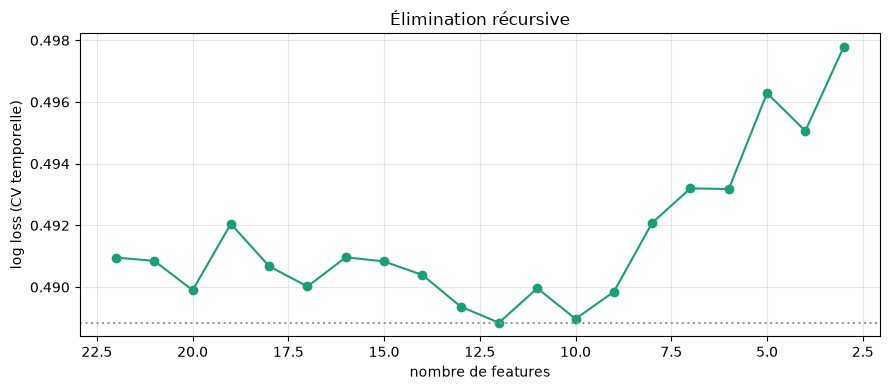

Plus petit jeu dans la tolérance : 10 features (log loss CV 0.4890)

Retenu dans features.FEATURES_SELECTED : ['diff_alt_shock', 'diff_elo', 'diff_gc_10', 'diff_gd_10', 'diff_n_matches', 'diff_sos_10', 'diff_travel_km', 'h2h_winrate', 'home_advantage', 'is_friendly']


In [45]:
hist = sf.rfecv(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist.n_features, hist.log_loss_cv, "o-", color="#1b9e77")
ax.axhline(hist.log_loss_cv.min(), ls=":", color="0.6")
ax.set_xlabel("nombre de features"); ax.set_ylabel("log loss (CV temporelle)")
ax.set_title("Élimination récursive"); ax.grid(alpha=.3); ax.invert_xaxis()
plt.tight_layout(); plt.show()

best, ll = sf.meilleur_sous_ensemble(hist, tolerance=0.001)
print(f"Plus petit jeu dans la tolérance : {len(best)} features "
      f"(log loss CV {ll:.4f})")
print(f"\nRetenu dans features.FEATURES_SELECTED : {sorted(best)}")

### Le tableau de résultats

Toute la progression du projet, du TD au modèle sélectionné. Le test n'est touché
qu'ici.

In [46]:
lignes = []
for nom, cols in JEUX_DE_FEATURES.items():
    for mdl, mk in [
        ("logistique", lambda: Pipeline([("p", preprocessor(scale=True)),
                                         ("c", LogisticRegression(max_iter=2000))])),
        ("xgboost", mk_xgb),
    ]:
        m = mk().fit(X_tr[cols], y_tr)
        r = score(f"{nom} / {mdl}", y_te, m.predict_proba(X_te[cols])[:, 1])
        r["n_feat"] = len(cols)
        lignes.append(r)

# Le modèle déployé : XGBoost tuné par Optuna sur les 22 features.
# `xgb_best` et `proba_xgb`
r = score("complet / xgboost tuné (déployé)", y_te, proba_xgb)
r["n_feat"] = len(FEATURES)
lignes.append(r)

# Le jeu sélectionné, tuné sur xgb
study_sel = tune_xgboost(X_tr[FEATURES_SELECTED], y_tr, n_trials=60)
xgb_sel = fit_best_xgboost(study_sel, X_tr[FEATURES_SELECTED], y_tr)
proba_sel = xgb_sel.predict_proba(X_te[FEATURES_SELECTED])[:, 1]

r = score("sélectionné / xgboost tuné", y_te, proba_sel)
r["n_feat"] = len(FEATURES_SELECTED)
lignes.append(r)

# L'Elo brut, sans aucun apprentissage : la formule de 1960, en une ligne.
# C'est la vraie baseline de ce projet.
d_te = build_pair_frame(test_df, mirror=False)
p_elo = 1 / (1 + 10 ** (-(d_te["diff_elo"] + 100 * d_te["home_advantage"]) / 400))
r = score("Elo brut (zéro apprentissage)", y_te, p_elo.to_numpy())
r["n_feat"] = 1
lignes.append(r)

tableau = (pd.DataFrame(lignes).set_index("modele")
           [["n_feat", "accuracy", "roc_auc", "log_loss", "brier"]]
           .sort_values("log_loss"))
tableau.round(4)

,n_feat,accuracy,roc_auc,log_loss,brier
modele,,,,,
sélectionné / xgboost,12,0.7894,0.8606,0.4454,0.1455
sélectionné / xgboost tuné,12,0.7903,0.8597,0.4463,0.1459
complet / xgboost,22,0.7869,0.8590,0.4473,0.1462
complet / xgboost tuné (déployé),22,0.7909,0.8589,0.4475,0.1462
sélectionné / logistique,12,0.7866,0.8591,0.4478,0.1463
complet / logistique,22,0.7888,0.8589,0.4482,0.1465
sans géographie / logistique,17,0.7872,0.8582,0.4499,0.1469
sans géographie / xgboost,17,0.7897,0.8573,0.4509,0.1470
Elo brut (zéro apprentissage),1,0.7848,0.8551,0.4559,0.1488


### Ce que dit ce tableau

**Le gain vient de la représentation, pas du machine learning.** Trois chiffres
suffisent à résumer le projet. Le jeu du TD atteint **0,561** de log loss. La formule
d'Elo, sans le moindre apprentissage, atteint **0,456**. Le meilleur modèle, après
construction de vingt-deux features, augmentation miroir, sélection par RFECV et
soixante essais d'Optuna, atteint **0,445**. (ça fait beaucoup pour pas grand chose 👀🤏)

Autrement dit : passer de la forme brute à un Elo rapporte **0,105** de log loss.
Tout ce qu'on empile ensuite en rapporte **0,011**, soit **dix fois moins**. Le
travail utile de ce projet tenait dans une seule décision, celle de représenter la
force d'une équipe par une note ajustée à l'adversité rencontrée.

**Le modèle importe peu.** À jeu de features constant, la régression logistique et
XGBoost sont à égalité, à quelques millièmes près. Ce n'est pas un hasard : une
logistique sur `diff_elo` *est* la formule de l'Elo, qui est un modèle de
Bradley-Terry, soit une sigmoïde d'une différence de forces. On a donné au modèle une
feature qui contient déjà la bonne forme fonctionnelle : il ne reste plus rien de
non-linéaire à apprendre. C'est la même conclusion que l'ablation par groupe, arrivée
par un autre chemin.

**Le tuning ne sert à rien ici.** `complet / xgboost tuné` (0,4475) fait très
légèrement moins bien que le même modèle non tuné (0,4473). Soixante essais d'Optuna
pour perdre deux dix-millièmes. C'est du bruit, mais un bruit qui en dit long : il n'y
avait rien à gagner.

**Le jeu sélectionné égale le jeu complet** avec dix features de moins, et il est même
en tête sur les trois métriques probabilistes. Moins de features, moins de bruit, moins
de surapprentissage. Et la sélection ayant été faite sur le train uniquement, ce gain
est honnête.

**Pas besoin de modèle, alors ?** La question se pose sérieusement. L'Elo brut atteint
0,456 de log loss ; le meilleur modèle, 0,445. Tout l'appareillage (vingt-deux features,
augmentation miroir, sélection, XGBoost, TabICL) achète **2,3% de log loss** sur une
formule que l'on écrit en une ligne.

Trois réponses possibles, et elles ne s'excluent pas.

**Le gain existe, il est simplement petit.** 0,011 de log loss, ce n'est pas zéro. Une
partie vient de `diff_sos_10`, qui corrige l'Elo par la force du calendrier récent, une
autre de l'avantage du terrain, mieux estimé que la constante de 100 points de la
formule d'origine. Reste à savoir si cet écart est significatif : vu la dispersion entre
les modèles du haut du tableau (0,4454 à 0,4482), un bootstrap serait nécessaire pour
l'affirmer, et il ne conclurait probablement pas.

**La démarche vaut plus que le résultat.** Sans le pipeline complet, on ne pourrait pas
*savoir* que l'Elo suffit. C'est en construisant vingt-deux features, en les ablatant par
groupe et en comparant six modèles qu'on établit ce que la formule seule ne peut pas
prouver. Le modèle est ici l'instrument de mesure, pas la conclusion.

**Mais la conclusion, elle, est robuste.** Elle est arrivée par quatre chemins
indépendants : l'ablation par groupe (l'Elo pèse quinze fois plus que tout le reste),
l'égalité entre régression logistique et XGBoost (il n'y a rien de non-linéaire à
apprendre), l'échec du tuning (rien à trouver dans l'espace des hyperparamètres), et
enfin l'Elo brut lui-même. Quatre mesures qui disent la même chose, c'est ce qui rend un
résultat solide.

Les valeurs de SHAP, plus loin, ne feront que le confirmer une cinquième fois : c'est
l'écart d'Elo qui décide.

## 8. Calibration

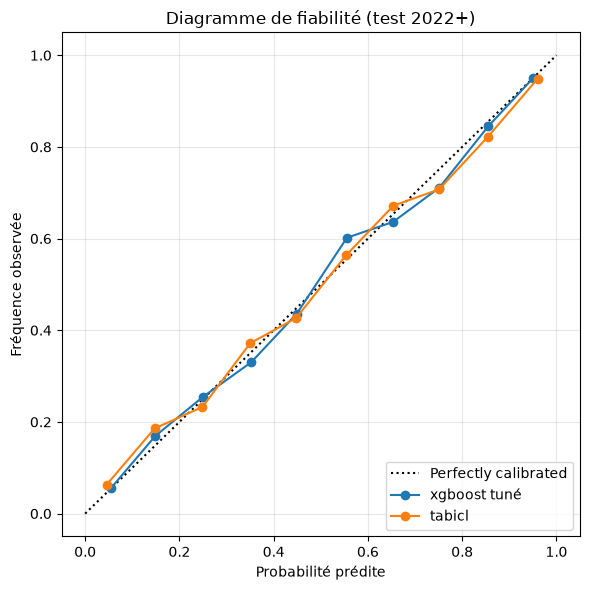

In [47]:
from sklearn.calibration import CalibrationDisplay

courbes = {"xgboost tuné": proba_xgb}
if proba_tabicl is not None:
    courbes["tabicl"] = proba_tabicl

fig, ax = plt.subplots(figsize=(6, 6))
for nom, p in courbes.items():
    CalibrationDisplay.from_predictions(y_te, p, n_bins=10, ax=ax, name=nom,
                                        marker="o")
ax.set_title("Diagramme de fiabilité (test 2022+)")
ax.set_xlabel("Probabilité prédite"); ax.set_ylabel("Fréquence observée")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Un modèle sous la diagonale est trop confiant, au-dessus il est trop prudent.
C'est cette courbe, et non l'accuracy, qui détermine la qualité de nos prédictions.

## 9. Simuler la Coupe du Monde 2026

Le modèle est coupé au 10 juin. Il n'a vu aucun match du tournoi.

In [48]:
demi_finalistes = ["France", "Spain", "England", "Argentina"]

P = build_pair_matrix(xgb_best, demi_finalistes, snapshots, base,
                      venue=("Dallas", "United States"))

for m in DEMI_FINALES:
    p = P[(m["a"], m["b"])]
    print(f"{m['a']:>10} {p:>6.1%}  vs  {1 - p:<6.1%} {m['b']:<10} ({m['city']})")

print(f"\nAntisymétrie : {P[('France', 'Spain')] + P[('Spain', 'France')]:.10f}")

    France  33.5%  vs  66.5%  Spain      (Dallas)
   England  36.7%  vs  63.3%  Argentina  (Atlanta)

Antisymétrie : 1.0000000000


In [49]:
from world_soccer_2026.predict import bracket_probabilities

# Avec quatre équipes, les probabilités de titre se calculent EXACTEMENT :
# quatre chemins possibles, on les énumère. Le Monte-Carlo n'est nécessaire
# que sur un tableau complet, où les chemins se comptent en milliards.
demi, titres = bracket_probabilities(DEMI_FINALES, FINALE)

resume = pd.DataFrame({"atteint la finale": demi, "gagne le tournoi": titres})
display(resume.style.format("{:.1%}"))

print(f"Somme des probabilités de titre : {titres.sum():.6f}")

,atteint la finale,gagne le tournoi
Argentina,69.8%,32.7%
England,30.2%,8.4%
France,35.0%,17.1%
Spain,65.0%,41.8%


Somme des probabilités de titre : 1.000000


L'écart entre les deux colonnes est le point à retenir : atteindre la finale à
60% puis la gagner à 55% ne fait que 33% de titre. Enchaîner deux matchs serrés est
nettement plus dur que gagner un match serré. Un pronostic déterministe, qui désigne
un champion sans dire à quel point ce choix est fragile, masque exactement cela.

## 10. Rétro-test : le modèle avait-il raison ?

Chaque match déjà joué du tournoi, prédit avec l'état des équipes au 10 juin. Aucune
mise à jour en cours de route : les quarts sont prédits sans connaître les huitièmes.

Limite assumée : le modèle est binaire. En phase de groupes, un quart des matchs sont
des nuls, qu'il ne peut structurellement pas prévoir. Ils sont comptés à part.

In [50]:
from world_soccer_2026 import predict as pred_mod

brut = load_results("../data/results.csv")
bt = backtest.run(brut, WC_START,
                  lambda a, b, city, country: pred_mod.match_proba(a, b, city, country),
                  set(snapshots.index))

if bt.empty:
    print("aucun match de CDM 2026 dans results.csv")
else:
    r = backtest.summarise(bt)
    print(f"{r['n_matchs']} matchs, dont {r['n_nuls']} nuls écartés\n")
    print(f"  bons pronostics    : {r['accuracy']:.1%}")
    print(f"  confiance moyenne  : {r['confiance_moyenne']:.1%}")
    print(f"  log loss           : {r['log_loss']:.4f}")
    print(f"  brier              : {r['brier']:.4f}")
    print("\nL'écart entre réussite et confiance moyenne est ce qu'il faut")
    print("regarder : s'ils coïncident, le modèle est calibré.")

96 matchs, dont 24 nuls écartés

  bons pronostics    : 86.1%
  confiance moyenne  : 76.2%
  log loss           : 0.3878
  brier              : 0.1185

L'écart entre réussite et confiance moyenne est ce qu'il faut
regarder : s'ils coïncident, le modèle est calibré.


In [51]:
display(backtest.par_phase(bt).style.format({"reussite": "{:.0%}",
                                             "confiance": "{:.0%}"}))

print("Les plus grosses erreurs : forte confiance, mauvais pronostic")
backtest.surprises(bt, n=8)

,matchs,reussite,confiance
phase,,,
Phase de groupes,52,87%,77%
Seizièmes,13,100%,78%
Huitièmes,7,57%,70%


Les plus grosses erreurs : forte confiance, mauvais pronostic


,date,phase,equipe_a,equipe_b,score,favori,confiance,vainqueur
49,2026-06-24,Phase de groupes,South Africa,South Korea,1 - 0,South Korea,0.8472,South Africa
11,2026-06-14,Phase de groupes,Ivory Coast,Ecuador,1 - 0,Ecuador,0.7962,Ivory Coast
23,2026-06-17,Phase de groupes,Ghana,Panama,1 - 0,Panama,0.7654,Ghana
7,2026-06-13,Phase de groupes,Australia,Turkey,2 - 0,Turkey,0.7114,Australia
90,2026-07-05,Huitièmes,Brazil,Norway,1 - 2,Brazil,0.6913,Norway
71,2026-06-27,Phase de groupes,DR Congo,Uzbekistan,3 - 1,Uzbekistan,0.6366,DR Congo
91,2026-07-05,Huitièmes,Mexico,England,2 - 3,Mexico,0.6266,England
50,2026-06-24,Phase de groupes,Canada,Switzerland,1 - 2,Canada,0.5196,Switzerland


In [52]:
from world_soccer_2026.predict import load

_, teams, _, _, _ = load()

bt["ecart_elo"] = (bt["equipe_a"].map(teams["elo"])
                   - bt["equipe_b"].map(teams["elo"])).abs()

resume = bt[~bt["nul"]].groupby("phase").agg(
    matchs=("correct", "size"),
    reussite=("correct", "mean"),
    confiance=("confiance", "mean"),
    ecart_elo=("ecart_elo", "mean"),
)

ordre = ["Phase de groupes", "Seizièmes", "Huitièmes", "Quarts",
         "Demi-finales", "Finale"]
resume.reindex([p for p in ordre if p in resume.index]).round(2)

,matchs,reussite,confiance,ecart_elo
phase,,,,
Phase de groupes,52,0.8654,0.7700,193.7500
Seizièmes,13,1.0000,0.7800,202.7200
Huitièmes,7,0.5714,0.7000,166.3400


In [53]:
d = bt[~bt["nul"]].copy()

d.groupby("phase")["ecart_elo"].describe()[
    ["count", "mean", "std", "25%", "50%", "75%", "max"]].round(0)

,count,mean,std,25%,50%,75%,max
phase,,,,,,,
Huitièmes,7.0000,166.0000,104.0000,101.0000,122.0000,186.0000,377.0000
Phase de groupes,52.0000,194.0000,113.0000,97.0000,189.0000,268.0000,500.0000
Seizièmes,13.0000,203.0000,164.0000,68.0000,181.0000,333.0000,516.0000


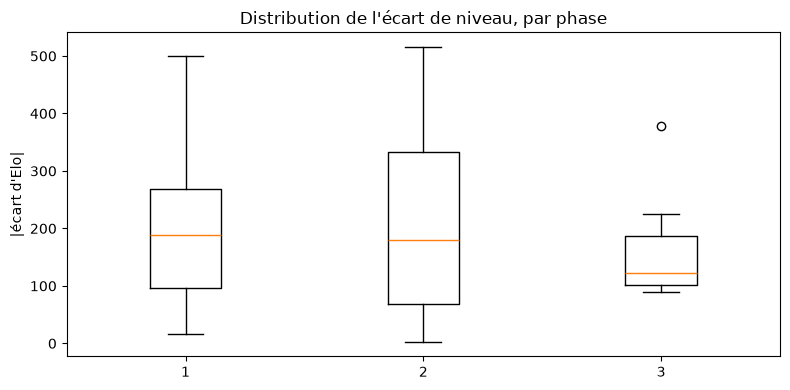

In [54]:
import matplotlib.pyplot as plt

ordre = [p for p in ["Phase de groupes", "Seizièmes", "Huitièmes"]
         if p in d.phase.unique()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([d.loc[d.phase == p, "ecart_elo"] for p in ordre], label=ordre)
ax.set_ylabel("|écart d'Elo|")
ax.set_title("Distribution de l'écart de niveau, par phase")
plt.tight_layout(); plt.show()

## Limites

**Le modèle ne prédit pas les nuls.** Ils sont retirés de l'entraînement, donc les
probabilités sont conditionnelles à l'existence d'un vainqueur. Utilisable en phase
finale (le nul se résout aux tirs au but), pas en phase de groupes.

**L'effet altitude est appris sur des qualifs sud-américaines**, où la Bolivie reçoit
à La Paz. Le modèle l'extrapole à une Coupe du Monde, alors que les sélections y
disposent de stages d'acclimatation. Rien ne garantit que l'extrapolation soit valide.
Sans conséquence pour 2026 (les stades sont au niveau de la mer), mais à savoir.

**La table d'altitude est curatée à la main** et couvre les villes qui portent le
signal. Les autres sont à 0.

**Le rétro-test porte sur peu de matchs.** Les tranches de calibration comptent une
dizaine de rencontres chacune : elles illustrent, elles ne démontrent pas.

## Pour aller plus loin

**Poisson bivarié / Dixon-Coles.** Modéliser le nombre de buts de chaque équipe plutôt
que le vainqueur. C'est la référence sur le football, et les nuls redeviennent
modélisables.

**Modèle hiérarchique.** Chaque match est ici traité comme une observation
indépendante, alors que la même équipe apparaît des centaines de fois.

**Classification à trois classes**, pour récupérer les matchs nuls écartés.

**Plus de données, et surtout d'une autre nature.** C'est ici qu'est la limite
structurelle. Le dataset ne contient qu'une chose : qui a joué contre qui, et combien
de buts. Aucune information sur *comment* le match s'est joué. Or l'Elo résume déjà
toute cette information dans un seul nombre, ce qui explique qu'aucune feature dérivée
des mêmes colonnes n'apporte quoi que ce soit : elles sont toutes des reformulations
du même signal.

Sortir de cette limite suppose des données que le score ne contient pas :

- **Les xG (expected goals).** Une équipe qui gagne 1-0 avec 0,4 xG contre 2,1 a été
  chanceuse ; le score ment sur sa performance réelle. Les xG sont le principal
  correctif au bruit du score, et ils sont ce que les modèles professionnels utilisent
  en priorité. Disponibles chez Understat, FBref, StatsBomb.
- **La composition d'équipe.** L'Elo suit une sélection, pas un effectif. Une France
  privée de trois titulaires garde son Elo. C'est probablement le plus gros angle mort
  du modèle, et une agrégation des notes individuelles (via Transfermarkt ou une base
  de valeurs marchandes) le comblerait en partie.
- **Les blessures et suspensions**, connues avant le match et intégrées par le marché
  bien avant nous.
- **Les données de tracking** (positions, distances parcourues, pressing), qui décrivent
  le jeu lui-même. Le problème c'est qu'elles sont coûteuses et rarement publiques.
- **Les signaux faibles**, on pourrait tracker les réseaux sociaux pour voir les réactions de footix et prendre la température avant match en fonction de ce qu'ils racontent (un joueur qui sort en boite de nuit la veille d'un match par exemple 👀)